# Zomato Bangalore Restaurant Data Analysis
### Exploratory Data Analysis using Python

# Introduction

The restaurant industry in Bangalore has grown rapidly due to increasing urbanization, changing food preferences and the expansion of online food delivery platforms such as Zomato. With thousands of restaurants operating across different locations and cuisines, understanding customer behavior and market trends has become important for restaurants to remain competitive.

This project focuses on analyzing Bangalore restaurant data from Zomato using Python and data analytics techniques. The dataset contains information related to restaurant ratings, customer votes, cuisines, pricing, online ordering facilities and restaurant locations.

The primary purpose of this project is to extract meaningful insights from raw restaurant data and understand factors influencing restaurant popularity, customer satisfaction and market demand. Through exploratory data analysis and visualization, the project aims to identify:

* High-demand restaurant locations
* Customer cuisine preferences
* Impact of online ordering services
* Relationship between pricing and ratings
* Most popular and highly engaged restaurants

The findings from this analysis can help restaurant businesses make better strategic decisions regarding pricing, location selection, online delivery integration and customer targeting strategies.


In [ ]:


import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("zomato.csv")

In [7]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


## Dataset Cleaning


In [8]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [9]:
df.drop(['url', 'phone', 'dish_liked', 'reviews_list', 'menu_item'], axis=1, inplace=True)

In [10]:
df.isnull().sum()

address                           0
name                              0
online_order                      0
book_table                        0
rate                           7775
votes                             0
location                         21
rest_type                       227
cuisines                         45
approx_cost(for two people)     346
listed_in(type)                   0
listed_in(city)                   0
dtype: int64

In [11]:
df = df[df['location'].notnull()]
df = df[df['cuisines'].notnull()]
df = df[df['approx_cost(for two people)'].notnull()]

In [12]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [13]:
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']
df = df[df['rate'].notnull()]

In [14]:
df['rate'] = df['rate'].str.split('/').str[0]

In [15]:
df['rate'] = pd.to_numeric(df['rate'])

In [16]:
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')
)

In [17]:
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41410 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      41410 non-null  object 
 1   name                         41410 non-null  object 
 2   online_order                 41410 non-null  object 
 3   book_table                   41410 non-null  object 
 4   rate                         41410 non-null  float64
 5   votes                        41410 non-null  int64  
 6   location                     41410 non-null  object 
 7   rest_type                    41263 non-null  object 
 8   cuisines                     41410 non-null  object 
 9   approx_cost(for two people)  41410 non-null  int64  
 10  listed_in(type)              41410 non-null  object 
 11  listed_in(city)              41410 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 4.1+ MB


In [20]:
df.head(10)

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari
5,"37, 5-1, 4th Floor, Bosco Court, Gandhi Bazaar...",Timepass Dinner,Yes,No,3.8,286,Basavanagudi,Casual Dining,North Indian,600,Buffet,Banashankari
6,"19/1, New Timberyard Layout, Beside Satellite ...",Rosewood International Hotel - Bar & Restaurant,No,No,3.6,8,Mysore Road,Casual Dining,"North Indian, South Indian, Andhra, Chinese",800,Buffet,Banashankari
7,"2469, 3rd Floor, 24th Cross, Opposite BDA Comp...",Onesta,Yes,Yes,4.6,2556,Banashankari,"Casual Dining, Cafe","Pizza, Cafe, Italian",600,Cafes,Banashankari
8,"1, 30th Main Road, 3rd Stage, Banashankari, Ba...",Penthouse Cafe,Yes,No,4.0,324,Banashankari,Cafe,"Cafe, Italian, Continental",700,Cafes,Banashankari
9,"2470, 21 Main Road, 25th Cross, Banashankari, ...",Smacznego,Yes,No,4.2,504,Banashankari,Cafe,"Cafe, Mexican, Italian, Momos, Beverages",550,Cafes,Banashankari


In [21]:
df.drop_duplicates(inplace=True)

## Dataset information

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41349 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      41349 non-null  object 
 1   name                         41349 non-null  object 
 2   online_order                 41349 non-null  object 
 3   book_table                   41349 non-null  object 
 4   rate                         41349 non-null  float64
 5   votes                        41349 non-null  int64  
 6   location                     41349 non-null  object 
 7   rest_type                    41202 non-null  object 
 8   cuisines                     41349 non-null  object 
 9   approx_cost(for two people)  41349 non-null  int64  
 10  listed_in(type)              41349 non-null  object 
 11  listed_in(city)              41349 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 4.1+ MB


In [23]:
df[['name', 'rate']].sort_values(by='rate', ascending=False).head(10)

,name,rate
21770,AB's - Absolute Barbecues,4.9
14740,Belgian Waffle Factory,4.9
26497,Asia Kitchen By Mainland China,4.9
4944,Byg Brewski Brewing Company,4.9
10389,AB's - Absolute Barbecues,4.9
27453,Asia Kitchen By Mainland China,4.9
31069,Asia Kitchen By Mainland China,4.9
8260,AB's - Absolute Barbecues,4.9
6746,Flechazo,4.9
19393,AB's - Absolute Barbecues,4.9


In [24]:
df.groupby('name')['rate'].mean().sort_values(ascending=False).head(10)

name
Byg Brewski Brewing Company                                                         4.900000
SantÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Spa Cuisine    4.900000
Asia Kitchen By Mainland China                                                      4.900000
Punjab Grill                                                                        4.871429
Belgian Waffle Factory                                                              4.844828
O.G. Variar & Sons                                                                  4.800000
The Pizza Bakery                                                                    4.800000
Flechazo                                                                            4.800000
AB's - Absolute Barbecues                                                           4.789474
Biergarten                                                                          4.766667
Name: rate, dtype: float64

In [25]:
text_cols = ['name', 'location', 'rest_type', 'cuisines', 'address']

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.encode('latin1', errors='ignore')
        .str.decode('utf-8', errors='ignore')
    )

In [26]:
df.groupby('name')['rate'].mean().sort_values(ascending=False).head(10)

name
Byg Brewski Brewing Company                         4.900000
SantÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Spa Cuisine    4.900000
Asia Kitchen By Mainland China                      4.900000
Punjab Grill                                        4.871429
Belgian Waffle Factory                              4.844828
O.G. Variar & Sons                                  4.800000
The Pizza Bakery                                    4.800000
Flechazo                                            4.800000
AB's - Absolute Barbecues                           4.789474
Biergarten                                          4.766667
Name: rate, dtype: float64

In [27]:
df['name'] = df['name'].str.replace(r'Ã.|Â.|â.|ð.|™|©', '', regex=True)

In [28]:
df.groupby('name')['rate'].mean().sort_values(ascending=False).head(10)

name
Asia Kitchen By Mainland China    4.900000
Byg Brewski Brewing Company       4.900000
Sant Spa Cuisine                  4.900000
Punjab Grill                      4.871429
Belgian Waffle Factory            4.844828
The Pizza Bakery                  4.800000
Flechazo                          4.800000
O.G. Variar & Sons                4.800000
AB's - Absolute Barbecues         4.789474
Biergarten                        4.766667
Name: rate, dtype: float64

In [29]:
df.describe()

,rate,votes,approx_cost(for two people)
count,41349.000000,41349.000000,41349.000000
mean,3.700063,351.077317,602.897434
std,0.440564,881.943523,464.014562
min,1.800000,0.000000,40.000000
25%,3.400000,21.000000,300.000000
50%,3.700000,73.000000,500.000000
75%,4.000000,275.000000,700.000000
max,4.900000,16832.000000,6000.000000


## Top Restaurant Locations

In [30]:
df['location'].value_counts().head(10)

location
BTM                      3900
Koramangala 5th Block    2295
HSR                      2003
Indiranagar              1798
JP Nagar                 1717
Jayanagar                1636
Whitefield               1573
Marathahalli             1425
Bannerghatta Road        1230
Koramangala 6th Block    1067
Name: count, dtype: int64

In [31]:
import matplotlib.pyplot as plt

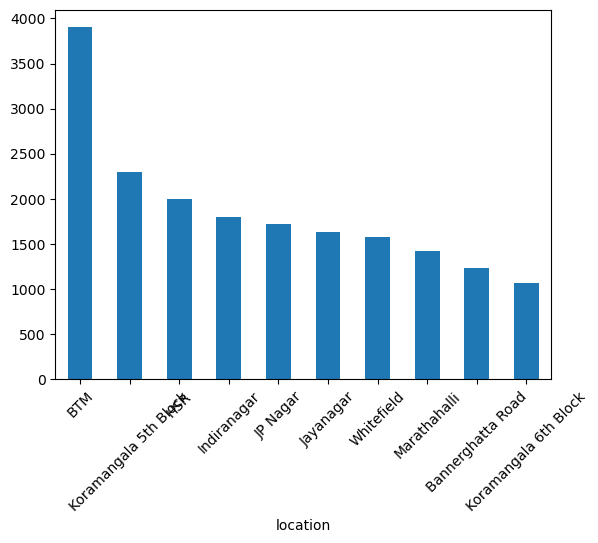

In [33]:
import matplotlib.pyplot as plt

df['location'].value_counts().head(10).plot(kind='bar')
plt.xticks(rotation=45)
plt.show()

## Online Ordering Distribution

In [34]:
df['online_order'].value_counts()

online_order
Yes    27151
No     14198
Name: count, dtype: int64

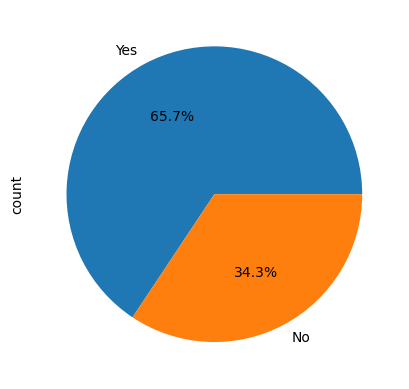

In [35]:
df['online_order'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

## Most Popular Cuisines

In [36]:
df['cuisines'].value_counts().head(10)


cuisines
North Indian                           2117
North Indian, Chinese                  1971
South Indian                           1231
Cafe                                    620
Bakery, Desserts                        613
Biryani                                 609
South Indian, North Indian, Chinese     561
Desserts                                545
Fast Food                               513
Chinese                                 409
Name: count, dtype: int64

## Rating Distribution

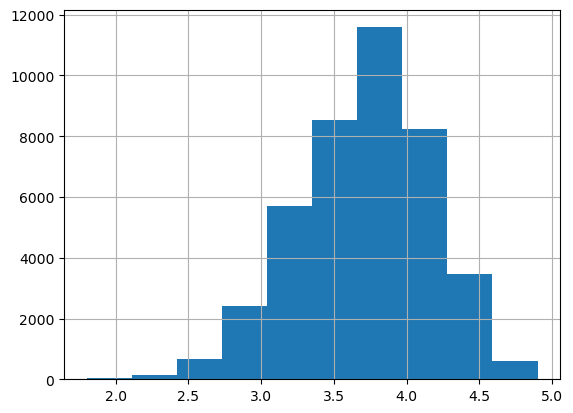

In [37]:
df['rate'].hist()
plt.show()

## Cost vs Rating Scatter Plot

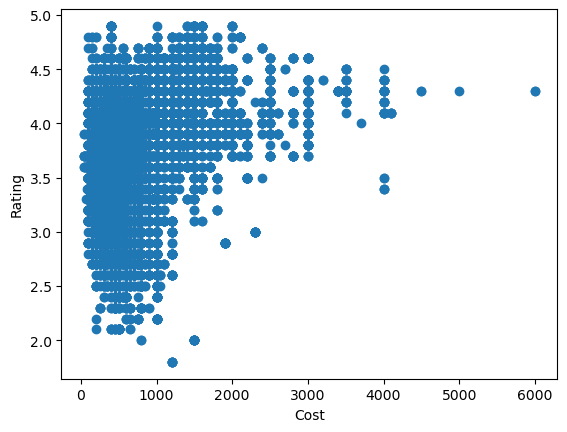

In [39]:
plt.scatter(df['approx_cost(for two people)'], df['rate'])
plt.xlabel('Cost')
plt.ylabel('Rating')
plt.show()

In [40]:
df.groupby('online_order')['rate'].mean()

online_order
No     3.657564
Yes    3.722286
Name: rate, dtype: float64

In [41]:
df.sort_values(by='votes', ascending=False)[['name', 'votes']].head(10)

,name,votes
49627,Byg Brewski Brewing Company,16832
50059,Byg Brewski Brewing Company,16832
49170,Byg Brewski Brewing Company,16832
4801,Byg Brewski Brewing Company,16345
3921,Byg Brewski Brewing Company,16345
4944,Byg Brewski Brewing Company,16345
18643,Toit,14956
19268,Toit,14956
36668,Truffles,14726
33913,Truffles,14723


## Most Popular Restaurants by Votes

In [42]:
df.groupby('name')['votes'].max().sort_values(ascending=False).head(10)

name
Byg Brewski Brewing Company    16832
Toit                           14956
Truffles                       14726
AB's - Absolute Barbecues      12121
The Black Pearl                10550
Big Pitcher                     9300
Onesta                          9085
Arbor Brewing Company           8419
Empire Restaurant               8304
Prost Brew Pub                  7871
Name: votes, dtype: int64

In [43]:
df['approx_cost(for two people)'].corr(df['rate'])

np.float64(0.3843025431402576)

In [44]:
df.to_csv("zomato_cleaned.csv", index=False)


# Key Insights

## Location Analysis

* BTM contains the highest concentration of restaurants in Bangalore.
* Koramangala and HSR also emerge as major restaurant hubs, indicating high commercial activity and strong food demand in these areas.

---

## Cuisine Analysis

* North Indian cuisine dominates the Bangalore restaurant ecosystem.
* North Indian and Chinese cuisine combinations are highly popular among customers.
* South Indian cuisine also maintains a strong market presence across the city.

---

## Online Ordering Trends

* Around 65% of restaurants support online ordering services.
* This highlights the increasing dominance of digital food delivery platforms in Bangalore’s restaurant industry.

---

## Rating Analysis

* Most restaurants have ratings between 3.5 and 4.2, indicating moderate-to-good customer satisfaction levels.
* Higher pricing does not necessarily guarantee better customer ratings.
* Affordable and mid-range restaurants are equally capable of achieving high ratings.

---

## Popular Restaurants

* Byg Brewski Brewing Company, Toit and Truffles received the highest customer engagement based on customer vote counts.
* These restaurants demonstrate strong brand popularity and customer retention.


# Conclusion

This project successfully analyzed Bangalore restaurant data from Zomato to understand customer behavior, restaurant trends and factors affecting restaurant performance. The analysis revealed that Bangalore’s restaurant ecosystem is highly competitive and strongly influenced by online food delivery culture.

The project identified major restaurant hubs such as BTM, Koramangala and HSR, highlighting areas with strong customer demand and commercial activity. Cuisine analysis showed that North Indian cuisine dominates the market, while online ordering services have become an important factor for restaurant operations and customer engagement.

The study also demonstrated that higher pricing does not necessarily guarantee better customer ratings, indicating that customer satisfaction depends more on food quality, service and overall dining experience. Additionally, highly popular restaurants such as Byg Brewski, Toit and Truffles showed exceptionally strong customer engagement based on vote counts.

Overall, this project provides valuable business insights that can help restaurant owners and food delivery platforms understand customer preferences, optimize pricing strategies, identify profitable locations and improve customer satisfaction. The project also demonstrates the practical application of data analytics in solving real-world business problems using Python and exploratory data analysis techniques.


# Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Jupyter Notebook


# Future Improvements

Future enhancements that can be added to this project include:

* Power BI Dashboard
* SQL Integration
* Advanced Visualizations
* Cuisine Recommendation System

